# Load cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load data from weather_cleaned.csv

df = pd.read_csv(
    './weather_cleaned.csv',
    parse_dates=[
        'last_updated',
        'sunrise',
        'sunset',
        'moonrise',
        'moonset'
        ]
)
df.shape

(144229, 33)

In [3]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_mph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_mph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')

# Feature Engineering

## Feature Creation

In [4]:
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['hour'] = df['last_updated'].dt.hour
df['day_of_year'] = df['last_updated'].dt.dayofyear
df.shape

(144229, 37)

In [5]:
df[['month','day','hour','day_of_year']].head()

,month,day,hour,day_of_year
0,5,16,13,137
1,5,16,10,137
2,5,16,9,137
3,5,16,10,137
4,5,16,9,137


In [6]:
import numpy as np

# Absolute latitude: distance from equator
df['abs_latitude'] = df['latitude'].abs()

# Hemisphere
df['hemisphere'] = np.where(
    df['latitude'] >= 0,
    'Northern',
    'Southern'
)

# Climate zone
def climate_zone(latitude):
    lat = abs(latitude)

    if lat < 23.5:
        return 'Tropical'
    elif lat < 40:
        return 'Subtropical'
    elif lat < 60:
        return 'Temperate'
    else:
        return 'Subpolar'

df['climate_zone'] = df['latitude'].apply(climate_zone)

In [7]:
df['climate_zone'].value_counts()

climate_zone
Tropical       71705
Temperate      37326
Subtropical    33718
Subpolar        1480
Name: count, dtype: int64

In [8]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_mph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_mph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination', 'month', 'day', 'hour',
       'day_of_year', 'abs_latitude', 'hemisphere', 'climate_zone'],
      dtype='str')

In [9]:
# Taking difference between highly correlated features

df['temperature_feel_diff'] = (
    df['feels_like_celsius']
    - df['temperature_celsius']
)

df['gust_wind_diff'] = (
    df['gust_mph']
    - df['wind_mph']
)

In [10]:
df['is_raining'] = (df['precip_mm'] > 0).astype(int)

In [11]:
df['is_daytime'] = (
    (df['last_updated'].dt.time >= df['sunrise'].dt.time) &
    (df['last_updated'].dt.time <= df['sunset'].dt.time)
).astype(int)

In [12]:
# Daylight duration
df['daylight_hours'] = (
    df['sunset'] - df['sunrise']
).dt.total_seconds() / 3600

# Hours since sunrise
df['hours_since_sunrise'] = (
    df['last_updated'] - df['sunrise']
).dt.total_seconds() / 3600

## Cyclic encoding for appropriate features

In [13]:
# months repeat
df['month_sin'] = np.sin(
    2 * np.pi * df['month'] / 12
)

df['month_cos'] = np.cos(
    2 * np.pi * df['month'] / 12
)

# hours repeat
df['hour_sin'] = np.sin(
    2 * np.pi * df['hour'] / 24
)

df['hour_cos'] = np.cos(
    2 * np.pi * df['hour'] / 24
)

# wind direction repeats
df['wind_degree_sin'] = np.sin(
    2 * np.pi * df['wind_degree'] / 360
)

df['wind_degree_cos'] = np.cos(
    2 * np.pi * df['wind_degree'] / 360
)

## Feature Selection

In [14]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_mph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_mph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination', 'month', 'day', 'hour',
       'day_of_year', 'abs_latitude', 'hemisphere', 'climate_zone',
       'temperature_feel_diff', 'gust_wind_diff', 'is_raining', 'is_daytime',
       'daylight_hours', 'hours_since_sunrise', 'month_sin', 'month_cos',
       'hour_sin', 'hour_cos', 'wind_degree_sin', 'wind_degree_cos'],
      dtype='str')

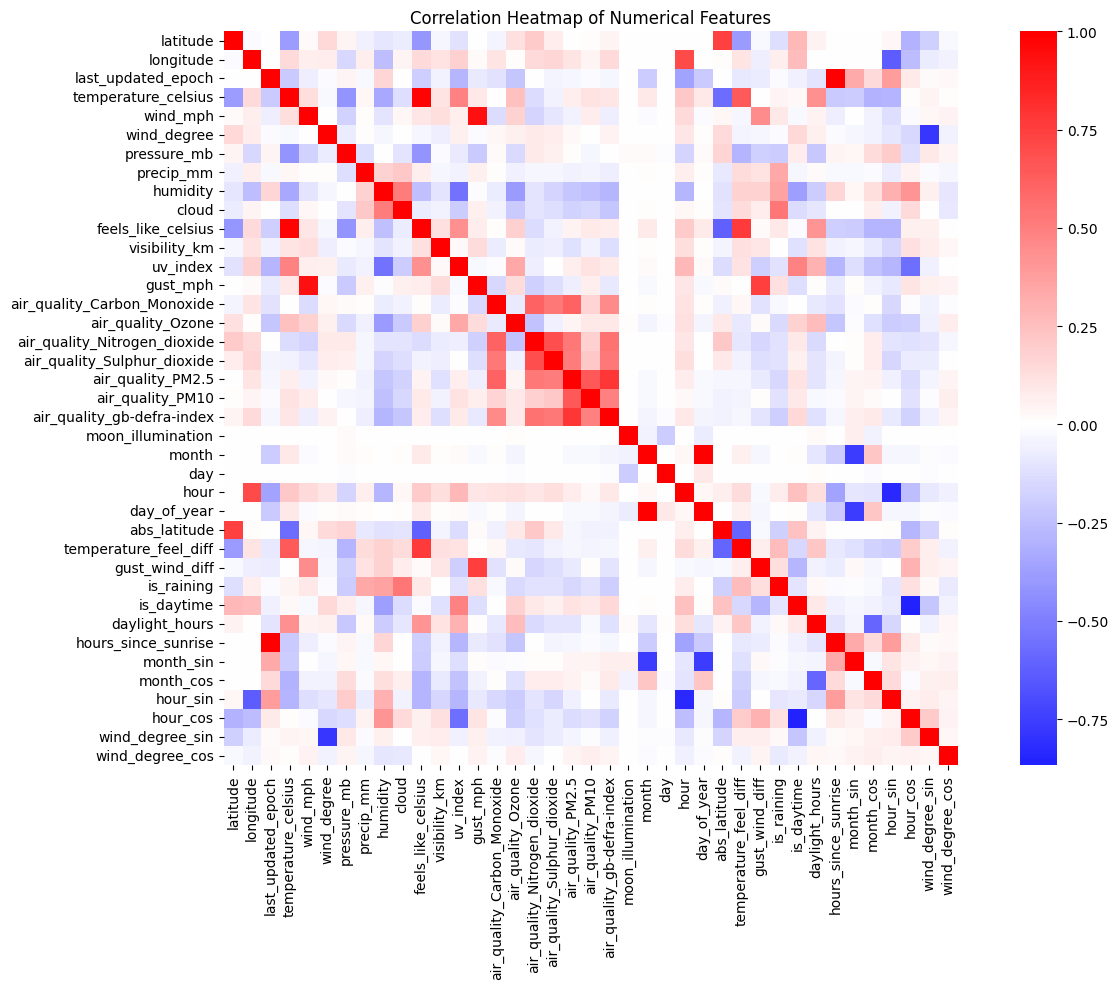

In [15]:
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Create correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='bwr', center=0, annot=False, square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [16]:
corr_target = (
    df.corr(numeric_only=True)['temperature_celsius']
      .sort_values(ascending=False)
)

corr_target.head(10)

temperature_celsius      1.000000
feels_like_celsius       0.983771
temperature_feel_diff    0.638505
uv_index                 0.488740
daylight_hours           0.434711
air_quality_Ozone        0.241641
hour                     0.216548
longitude                0.141400
wind_mph                 0.126194
air_quality_PM10         0.111067
Name: temperature_celsius, dtype: float64

In [17]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_mph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_mph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination', 'month', 'day', 'hour',
       'day_of_year', 'abs_latitude', 'hemisphere', 'climate_zone',
       'temperature_feel_diff', 'gust_wind_diff', 'is_raining', 'is_daytime',
       'daylight_hours', 'hours_since_sunrise', 'month_sin', 'month_cos',
       'hour_sin', 'hour_cos', 'wind_degree_sin', 'wind_degree_cos'],
      dtype='str')

In [18]:
# dropping columns
df = df.drop(columns=['feels_like_celsius', 'gust_mph'])

df = df.drop(columns=['last_updated_epoch'])

df = df.drop(columns=['month', 'hour', 'wind_degree', 'wind_direction'])

df = df.drop(columns=['country', 'location_name', 'timezone'])

df = df.drop(columns=['sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase'])

print(df.shape)
df.columns


(144229, 37)


Index(['latitude', 'longitude', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_mph', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'visibility_km', 'uv_index', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_gb-defra-index', 'moon_illumination', 'day', 'day_of_year',
       'abs_latitude', 'hemisphere', 'climate_zone', 'temperature_feel_diff',
       'gust_wind_diff', 'is_raining', 'is_daytime', 'daylight_hours',
       'hours_since_sunrise', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos',
       'wind_degree_sin', 'wind_degree_cos'],
      dtype='str')

In [19]:
# print categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['condition_text', 'hemisphere', 'climate_zone'], dtype='str')


C:\Users\kmddg\AppData\Local\Temp\ipykernel_55996\963351911.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## Feature Encoding

In [20]:
categorical_cols = [
    'condition_text',
    'hemisphere',
    'climate_zone'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [22]:
df.shape

(144229, 86)

In [21]:
# save df to weather_features.csv
df.to_csv('./weather_features.csv', index=False)